# EchoFactory - FAN: Evaluasi & Export ONNX (KNN Scoring)


In [45]:
import os, json, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MACHINE_TYPE = 'fan'

# Path untuk Model (ada di folder fanEchofac3)
MODEL_DIR = '/kaggle/input/notebooks/muhammadmuhibin/fanechofac3'
model_path = f'{MODEL_DIR}/stgram_mfn_{MACHINE_TYPE}_v2.pt'

# Path untuk Feature Data normal/abnormal (ditambahkan /features)
FEAT_DIR = '/kaggle/input/notebooks/muhammadmuhibin/fanechofac2/features'
# Jika file .pt berada di subfolder features, gunakan:
# FEAT_DIR = '/kaggle/input/notebooks/muhammadmuhibin/fanechofac2/features'

In [46]:
import math

class ConvBNPReLU(nn.Module):
    def __init__(self, ic, oc, k=3, s=1, p=1, g=1):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(ic, oc, k, s, p, groups=g, bias=False), nn.BatchNorm2d(oc), nn.PReLU(oc))
    def forward(self, x): return self.net(x)

class DepthwiseSep(nn.Module):
    def __init__(self, ic, oc, s=1):
        super().__init__()
        self.net = nn.Sequential(ConvBNPReLU(ic, ic, s=s, g=ic), ConvBNPReLU(ic, oc, k=1, p=0))
    def forward(self, x): return self.net(x)

class MobileFaceNet(nn.Module):
    def __init__(self, ed=256):
        super().__init__()
        self.enc = nn.Sequential(
            ConvBNPReLU(1, 32, s=2), DepthwiseSep(32, 64),
            DepthwiseSep(64, 128, s=2), DepthwiseSep(128, 128),
            DepthwiseSep(128, 256, s=2), DepthwiseSep(256, 256),
            DepthwiseSep(256, 512, s=2), nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(512, ed), nn.BatchNorm1d(ed))
    def forward(self, x): return self.head(self.enc(x))

class ArcFace(nn.Module):
    """ArcFace diload ulang agar arc.W (class centers) tersedia"""
    def __init__(self, ed, nc, s=32.0, m=0.5):
        super().__init__()
        self.s, self.m = s, m
        self.W = nn.Parameter(torch.FloatTensor(nc, ed))
        nn.init.xavier_uniform_(self.W)
        self.cos_m = math.cos(m); self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m); self.mm = math.sin(math.pi - m) * m
    def forward(self, feat, labels):
        cos = F.normalize(feat, 1) @ F.normalize(self.W, 1).T
        sin = (1.0 - cos ** 2 + 1e-8).sqrt()
        phi = cos * self.cos_m - sin * self.sin_m
        phi = torch.where(cos > self.th, phi, cos - self.mm)
        one_hot = F.one_hot(labels, cos.shape[1]).float()
        out = (one_hot * phi + (1.0 - one_hot) * cos) * self.s
        return F.cross_entropy(out, labels)

class STgramMFN(nn.Module):
    def __init__(self, nc, ed=256):
        super().__init__()
        self.mel, self.tgram = MobileFaceNet(ed), MobileFaceNet(ed)
        self.fuse = nn.Sequential(nn.Linear(ed * 2, ed), nn.BatchNorm1d(ed), nn.PReLU(ed))
        # ArcFace disertakan agar arc.W bisa di-load dari checkpoint
        self.arc = ArcFace(ed, nc)
    def forward(self, mel, tg):
        feat = self.fuse(torch.cat([self.mel(mel), self.tgram(tg)], dim=1))
        return F.normalize(feat, dim=1)

print('Model classes defined dengan ArcFace weights')


Model classes defined dengan ArcFace weights


In [47]:
@torch.no_grad()
def compute_pauc(labels, scores, max_fpr=0.1):
    return roc_auc_score(labels, scores, max_fpr=max_fpr)

@torch.no_grad()
def get_embeddings_with_labels(model, feat_dir, machine, cond):
    # Load data ke CPU agar tidak langsung memakan VRAM GPU
    data = torch.load(os.path.join(feat_dir, f'{machine}_{cond}.pt'), map_location='cpu')
    mel_feats = data['features'][:, 0:1]
    tg_feats  = data['features'][:, 1:2]
    labels    = data['labels']
    
    # Batch size diperkecil ke 64 agar lebih aman dari OutOfMemory
    dl = DataLoader(TensorDataset(mel_feats, tg_feats, labels), batch_size=64, shuffle=False)
    
    model.eval()
    embs, lbls = [], []
    for mb, tb, lb in dl:
        # Transfer batch ke GPU hanya saat forward pass
        out = model(mb.to(device), tb.to(device)).cpu()
        embs.append(out)
        lbls.append(lb)
        
    return torch.cat(embs), torch.cat(lbls)

@torch.no_grad()
def compute_arcface_anomaly_score(embeddings, labels, arc_W):
    arc_W_cpu  = arc_W.cpu()
    arc_W_norm = F.normalize(arc_W_cpu, dim=1)
    embs_norm  = F.normalize(embeddings.float().cpu(), dim=1)
    labels_cpu = labels.cpu()
    scores = []
    for i in range(len(embs_norm)):
        lid = min(int(labels_cpu[i].item()), arc_W_norm.shape[0] - 1)
        cos_sim = (embs_norm[i:i+1] @ arc_W_norm[lid:lid+1].T).item()
        scores.append(1.0 - cos_sim)
    return np.array(scores)

from sklearn.decomposition import PCA
from sklearn.covariance import EmpiricalCovariance

def compute_mahalanobis_score(normal_embs, normal_labels, test_embs, test_labels, pca_dim=64):
    """
    Mahalanobis Distance per Machine ID:
    1. Fit PCA untuk reduce dimensi (256 -> pca_dim) agar kovarians tidak singular
    2. Fit Gaussian per ID dari data normal
    3. Score test sample = Mahalanobis distance ke distribusi Gaussian ID-nya
    """
    ne_np   = normal_embs.float().cpu().numpy()
    te_np   = test_embs.float().cpu().numpy()
    n_lbls  = normal_labels.cpu().numpy()
    t_lbls  = test_labels.cpu().numpy()

    # PCA global untuk semua normal data
    pca = PCA(n_components=pca_dim, random_state=42)
    pca.fit(ne_np)
    ne_pca = pca.transform(ne_np)
    te_pca = pca.transform(te_np)

    # Fit Gaussian (mean + covariance) per Machine ID
    unique_ids = np.unique(n_lbls)
    gaussians = {}
    for uid in unique_ids:
        mask = (n_lbls == uid)
        clf  = EmpiricalCovariance(assume_centered=False)
        clf.fit(ne_pca[mask])
        gaussians[int(uid)] = clf
        print(f'  Fitted Gaussian for ID {uid}: n_samples={mask.sum()}')

    # Hitung Mahalanobis distance per sample
    scores = []
    for i in range(len(te_pca)):
        lid = int(t_lbls[i])
        if lid not in gaussians:
            lid = list(gaussians.keys())[0]
        clf = gaussians[lid]
        dist = clf.mahalanobis(te_pca[i:i+1])[0]
        scores.append(float(dist))
    return np.array(scores)

print('Scoring functions siap (ArcFace + Mahalanobis)')

Scoring functions siap (ArcFace + Mahalanobis)


In [48]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

arc.W shape: torch.Size([4, 256])
Normal embs: torch.Size([4075, 256]) | Abnormal embs: torch.Size([1475, 256])

[ArcFace Cosine]    AUC=0.5980 | pAUC=0.6918

Fitting Mahalanobis (PCA-64)...
  Fitted Gaussian for ID 0: n_samples=1011
  Fitted Gaussian for ID 1: n_samples=1016
  Fitted Gaussian for ID 2: n_samples=1033
  Fitted Gaussian for ID 3: n_samples=1015
  Fitted Gaussian for ID 0: n_samples=1011
  Fitted Gaussian for ID 1: n_samples=1016
  Fitted Gaussian for ID 2: n_samples=1033
  Fitted Gaussian for ID 3: n_samples=1015
[Mahalanobis-64]    AUC=0.7052 | pAUC=0.6911

Fitting Mahalanobis (PCA-32)...
  Fitted Gaussian for ID 0: n_samples=1011
  Fitted Gaussian for ID 1: n_samples=1016
  Fitted Gaussian for ID 2: n_samples=1033
  Fitted Gaussian for ID 3: n_samples=1015
  Fitted Gaussian for ID 0: n_samples=1011
  Fitted Gaussian for ID 1: n_samples=1016
  Fitted Gaussian for ID 2: n_samples=1033
  Fitted Gaussian for ID 3: n_samples=1015
[Mahalanobis-32]    AUC=0.7016 | pAUC=0.690

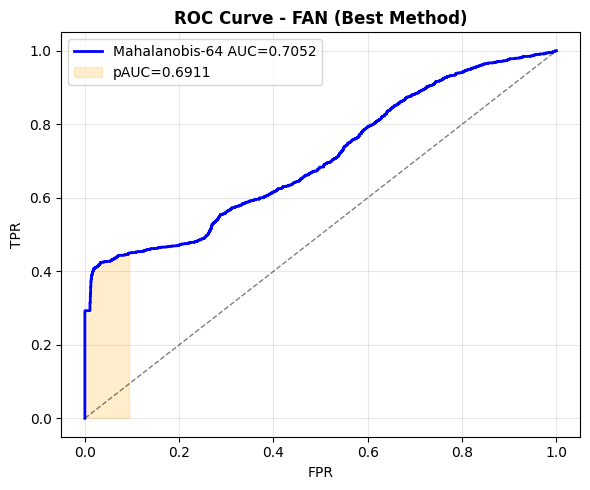

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 15.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 14.4 MB/s eta 0:00:00
[torch.onnx] Obtain model graph for `STgramMFN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `STgramMFN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅

ONNX Exported: /kaggle/working/stgram_mfn_fan.onnx
inference_config saved.


In [49]:
if os.path.exists(model_path):
    ck = torch.load(model_path, map_location='cpu')

    model = STgramMFN(ck['n_classes'], ck['embed_dim']).to(device)
    model.load_state_dict(ck['model_state'], strict=True)
    model.eval()

    arc_W = ck['model_state']['arc.W'].cpu()
    print(f'arc.W shape: {arc_W.shape}')

    ne, n_lbls = get_embeddings_with_labels(model, FEAT_DIR, MACHINE_TYPE, 'normal')
    ae, a_lbls = get_embeddings_with_labels(model, FEAT_DIR, MACHINE_TYPE, 'abnormal')
    print(f'Normal embs: {ne.shape} | Abnormal embs: {ae.shape}')

    best_auc, best_method, best_ns, best_as_ = 0, '', None, None
    all_results = {}

    # Metode 1: ID-Specific ArcFace Cosine
    ns1  = compute_arcface_anomaly_score(ne, n_lbls, arc_W)
    as1_ = compute_arcface_anomaly_score(ae, a_lbls, arc_W)
    sc1  = np.concatenate([ns1, as1_])
    lb1  = np.concatenate([np.zeros(len(ns1)), np.ones(len(as1_))])
    auc1 = roc_auc_score(lb1, sc1)
    pa1  = compute_pauc(lb1, sc1)
    all_results['ArcFace Cosine'] = auc1
    print(f'\n[ArcFace Cosine]    AUC={auc1:.4f} | pAUC={pa1:.4f}')
    if auc1 > best_auc:
        best_auc, best_method = auc1, 'ArcFace Cosine'
        best_ns, best_as_ = ns1, as1_

    # Metode 2: Mahalanobis PCA-64
    print('\nFitting Mahalanobis (PCA-64)...')
    ns2  = compute_mahalanobis_score(ne, n_lbls, ne, n_lbls, pca_dim=64)
    as2_ = compute_mahalanobis_score(ne, n_lbls, ae, a_lbls, pca_dim=64)
    sc2  = np.concatenate([ns2, as2_])
    lb2  = np.concatenate([np.zeros(len(ns2)), np.ones(len(as2_))])
    auc2 = roc_auc_score(lb2, sc2)
    pa2  = compute_pauc(lb2, sc2)
    all_results['Mahalanobis-64'] = auc2
    print(f'[Mahalanobis-64]    AUC={auc2:.4f} | pAUC={pa2:.4f}')
    if auc2 > best_auc:
        best_auc, best_method = auc2, 'Mahalanobis-64'
        best_ns, best_as_ = ns2, as2_

    # Metode 3: Mahalanobis PCA-32
    print('\nFitting Mahalanobis (PCA-32)...')
    ns3  = compute_mahalanobis_score(ne, n_lbls, ne, n_lbls, pca_dim=32)
    as3_ = compute_mahalanobis_score(ne, n_lbls, ae, a_lbls, pca_dim=32)
    sc3  = np.concatenate([ns3, as3_])
    lb3  = np.concatenate([np.zeros(len(ns3)), np.ones(len(as3_))])
    auc3 = roc_auc_score(lb3, sc3)
    pa3  = compute_pauc(lb3, sc3)
    all_results['Mahalanobis-32'] = auc3
    print(f'[Mahalanobis-32]    AUC={auc3:.4f} | pAUC={pa3:.4f}')
    if auc3 > best_auc:
        best_auc, best_method = auc3, 'Mahalanobis-32'
        best_ns, best_as_ = ns3, as3_

    # Summary
    print(f'\n=== HASIL TERBAIK: [{best_method}] ===')
    print(f' AUC  Score : {best_auc:.4f}')
    final_sc = np.concatenate([best_ns, best_as_])
    final_lb = np.concatenate([np.zeros(len(best_ns)), np.ones(len(best_as_))])
    final_pa = compute_pauc(final_lb, final_sc)
    fpr, tpr, thr = roc_curve(final_lb, final_sc)
    best_thr = float(thr[np.argmax(tpr - fpr)])
    print(f' pAUC Score : {final_pa:.4f}')
    print(f' Threshold  : {best_thr:.4f}')
    print(f' Normal   scores: min={best_ns.min():.4f}, max={best_ns.max():.4f}, mean={best_ns.mean():.4f}')
    print(f' Abnormal scores: min={best_as_.min():.4f}, max={best_as_.max():.4f}, mean={best_as_.mean():.4f}')

    # ROC Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'{best_method} AUC={best_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    plt.fill_between(fpr[fpr <= 0.1], tpr[fpr <= 0.1], alpha=0.2, color='orange', label=f'pAUC={final_pa:.4f}')
    plt.title(f'ROC Curve - {MACHINE_TYPE.upper()} (Best Method)', fontweight='bold')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/roc_{MACHINE_TYPE}.png', dpi=150)
    plt.show()

    # Export ONNX
    !pip install -q onnx onnxscript
    m_cpu = STgramMFN(ck['n_classes'], ck['embed_dim'])
    m_cpu.load_state_dict(ck['model_state'], strict=True)
    m_cpu.eval()
    onnx_path = f'/kaggle/working/stgram_mfn_{MACHINE_TYPE}.onnx'
    torch.onnx.export(m_cpu, (torch.randn(1,1,128,128), torch.randn(1,1,128,128)), onnx_path, input_names=['mel','tgram'], output_names=['embedding'])
    print(f'\nONNX Exported: {onnx_path}')

    # Simpan inference config
    cfg = {'machine': MACHINE_TYPE, 'model': f'stgram_mfn_{MACHINE_TYPE}.onnx',
           'auc': float(best_auc), 'pauc': float(final_pa), 'threshold': float(best_thr),
           'scoring': best_method, 'all_results': all_results,
           'embed_dim': ck['embed_dim'], 'n_classes': ck['n_classes'],
           'mel_params': {'n_mels': 128, 'n_fft': 1024, 'hop_length': 512},
           'tgram_params': {'n_mels': 128, 'n_fft': 512, 'hop_length': 512}}
    with open(f'/kaggle/working/inference_config_{MACHINE_TYPE}.json', 'w') as f:
        json.dump(cfg, f, indent=2)
    print('inference_config saved.')
